## Recitation 6: FV cont'd + FE Methods

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots  # noqa

from matplotlib.patches import Polygon
from matplotlib.animation import FuncAnimation

%matplotlib inline

### Problem 1

In [2]:
def godunov_flux(uL, uR):
    flux = np.zeros_like(uL)
    for i in range(len(uL)):
        if uL[i] > uR[i]:
            # shock
            s = 0.5 * (uL[i] + uR[i])
            flux[i] = 0.5 * uL[i] ** 2 if s > 0 else 0.5 * uR[i] ** 2
        else:
            # rarefaction
            if uL[i] >= 0:
                flux[i] = 0.5 * uL[i] ** 2
            elif uR[i] <= 0:
                flux[i] = 0.5 * uR[i] ** 2
            else:
                flux[i] = 0.0
    return flux

In [3]:
def animation(A, B, filename):
    Nx = 50
    x = np.linspace(-2, 2, Nx)
    dx = x[1] - x[0]
    CFL = 0.1

    def initial_condition(x):
        return np.where(x < 0, A, B)

    def exact_solution(x, t):
        u = np.zeros_like(x)
        if A > B:
            s = 0.5 * (A + B)
            u = np.where(x < s * t, A, B)
        else:
            u[x < A * t] = A
            u[x > B * t] = B
            mask = (x >= A * t) & (x <= B * t)
            u[mask] = x[mask] / t if t > 0 else 0
        return u

    u = initial_condition(x)
    plt.style.use(["science", "ieee", "grid"])
    fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
    (line_num,) = ax.plot(x, u, label="Numerical", lw=2)
    (line_ex,) = ax.plot(x, u, "--", label="Exact", lw=2)

    ax.set_ylim(min(A, B) - 0.5, max(A, B) + 0.5)
    ax.set_title("Burgers Equation Animation")
    ax.legend()
    ax.grid()

    def step():
        u = initial_condition(x)
        t = 0.0
        while True:
            dt = CFL * dx / (np.max(np.abs(u)) + 1e-6)
            uL = u[:-1]
            uR = u[1:]
            F = godunov_flux(uL, uR)

            u_new = u.copy()
            u_new[1:-1] -= dt / dx * (F[1:] - F[:-1])

            u = u_new
            t += dt
            yield u, t

    k = step()

    def update(_):
        for _ in range(1):
            u, t = next(k)
            line_num.set_ydata(u)
            line_ex.set_ydata(exact_solution(x, t))
            ax.set_title(f"t = {t:.3f}")

        return line_num, line_ex

    ani = FuncAnimation(fig, update, frames=100, interval=20)
    ani.save(filename, writer="pillow")
    plt.close(fig)


animation(2.0, 0.0, "../out/burgers_animation_shock.gif")
animation(0.0, 2.0, "../out/burgers_animation_rarefaction.gif")

![shock](../out/burgers_animation_shock.gif)

![rarefaction](../out/burgers_animation_rarefaction.gif)

Estimated order ≈ 1.046


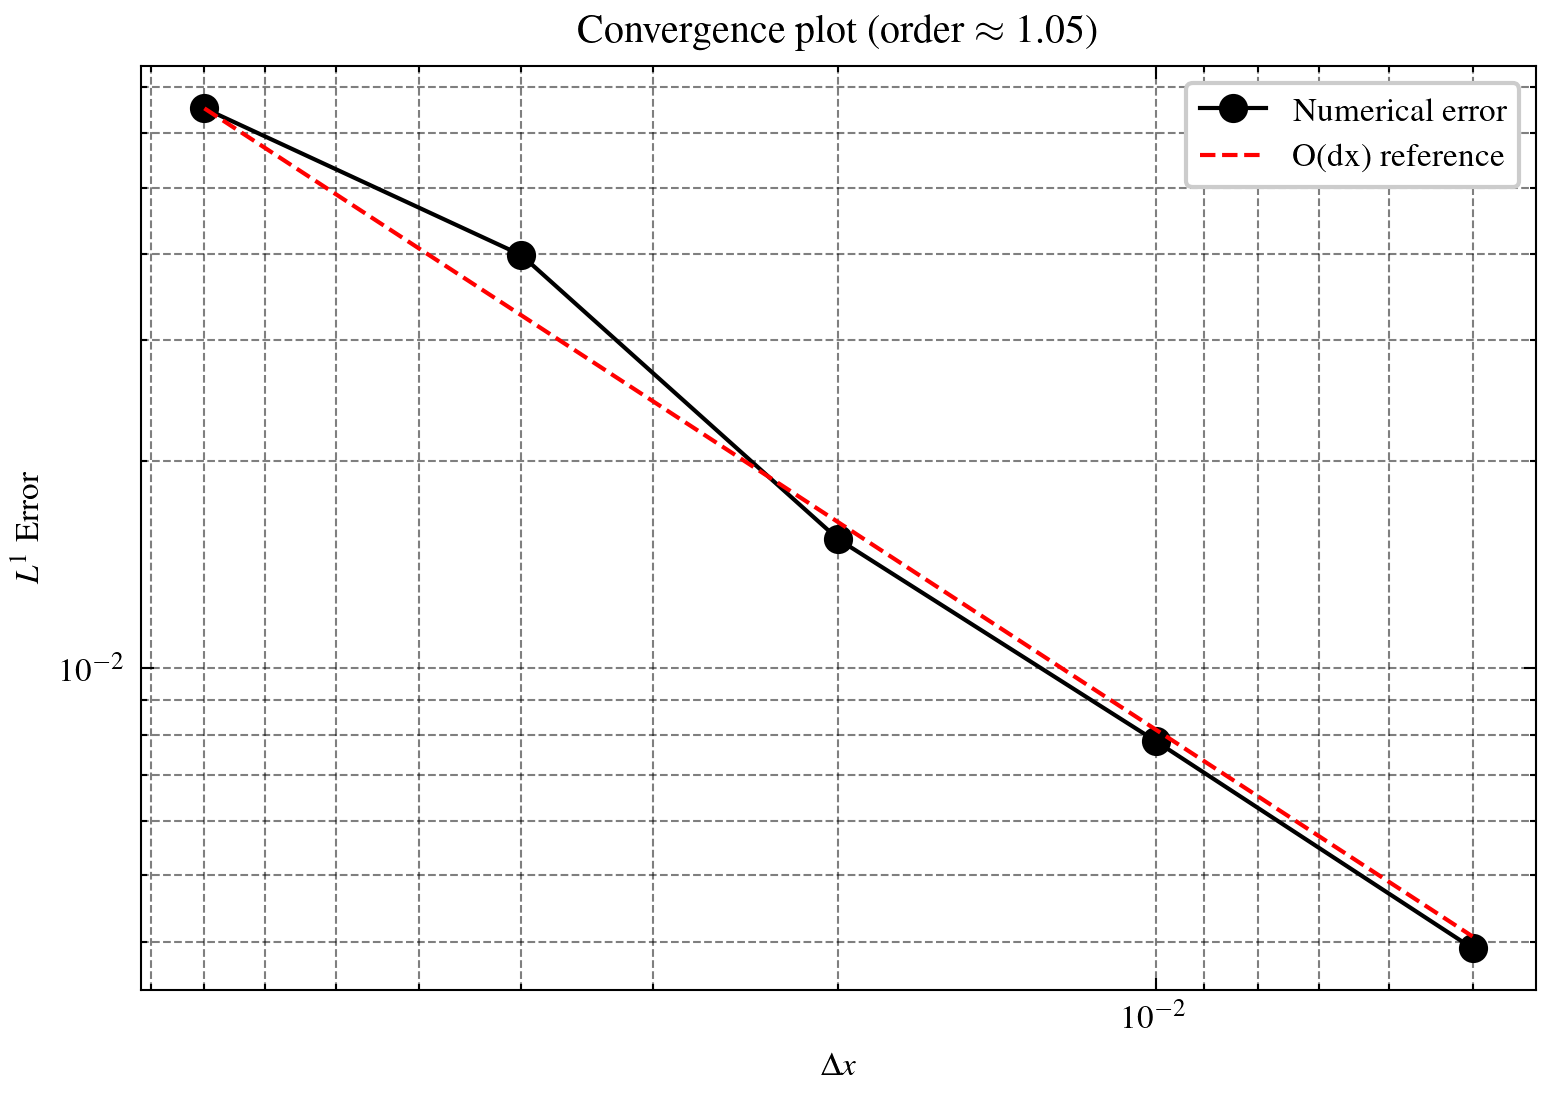

Estimated order ≈ 0.741


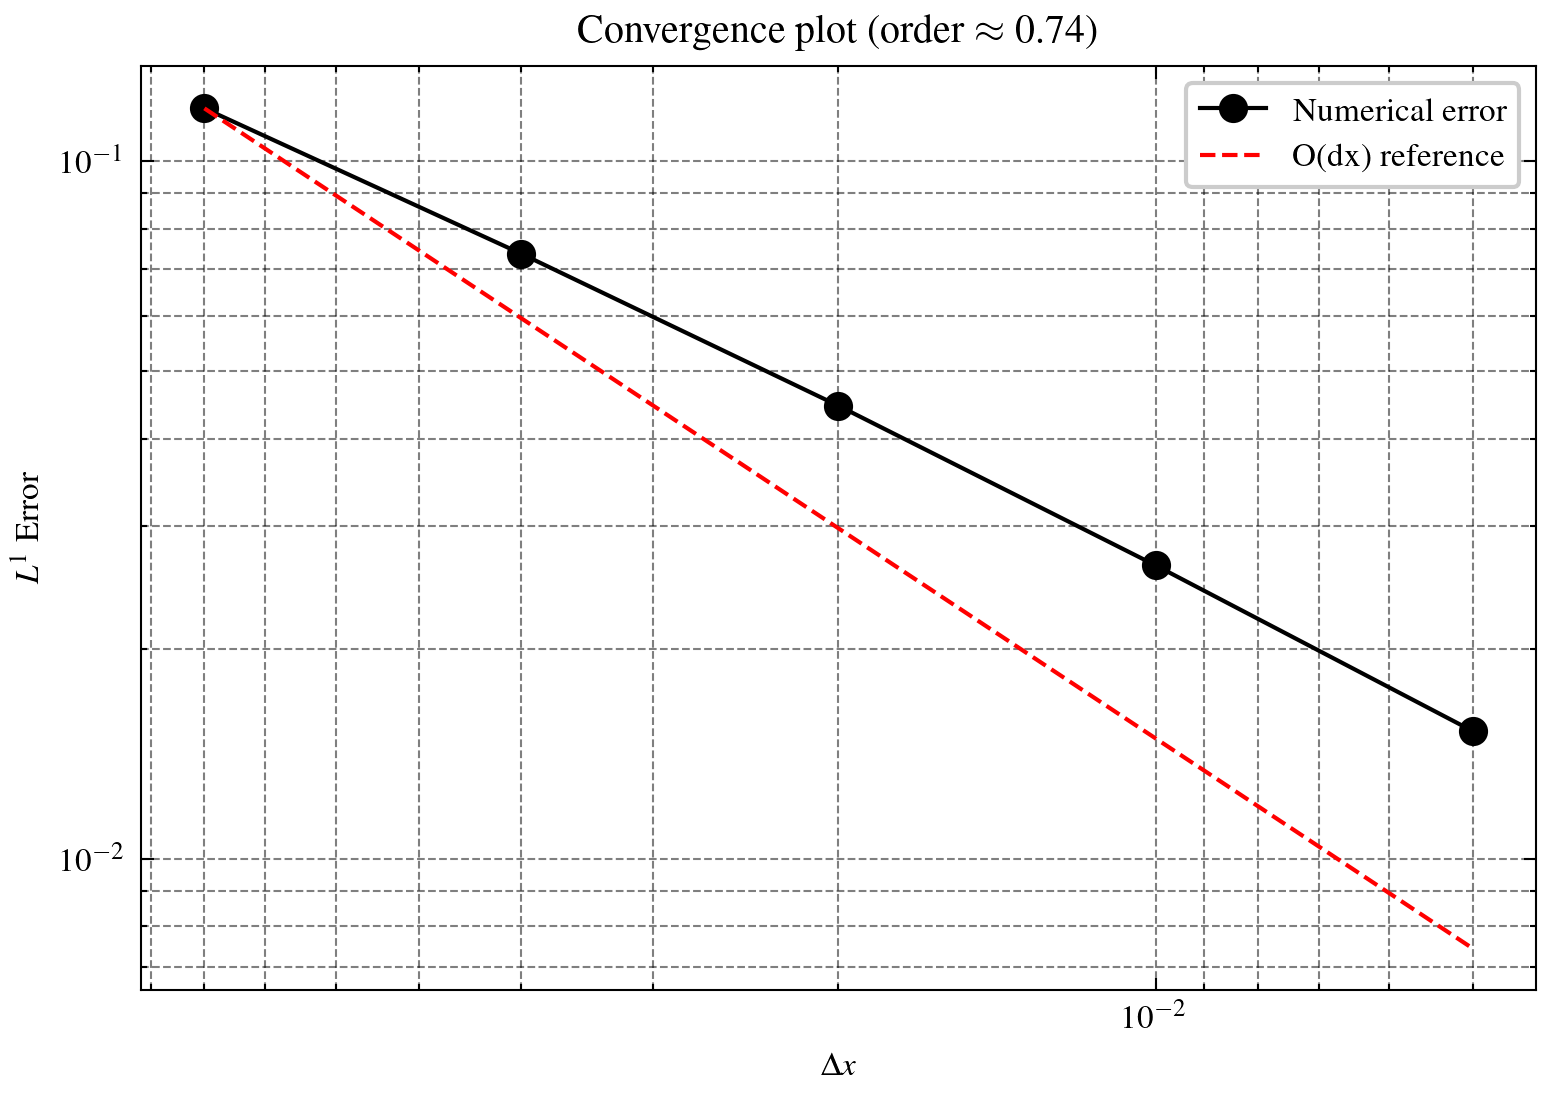

In [4]:
def solve(N, A, B, t_final=0.5):
    x = np.linspace(-2, 2, N)
    dx = x[1] - x[0]
    CFL = 0.8

    u = np.where(x < 0, A, B).astype(float)
    t = 0.0

    while t < t_final:
        dt = CFL * dx / (np.max(np.abs(u)) + 1e-6)
        if t + dt > t_final:
            dt = t_final - t

        F = godunov_flux(u[:-1], u[1:])
        u[1:-1] -= dt / dx * (F[1:] - F[:-1])
        t += dt

    return x, u


def exact(x, t, A, B):
    u = np.zeros_like(x)
    if A > B:
        s = 0.5 * (A + B)
        u = np.where(x < s * t, A, B)
    else:
        u[x < A * t] = A
        u[x > B * t] = B
        mask = (x >= A * t) & (x <= B * t)
        u[mask] = x[mask] / t
    return u


def compute_error(N, A, B):
    x, u_num = solve(N, A, B)
    u_ex = exact(x, 0.5, A, B)
    dx = x[1] - x[0]
    return np.sum(np.abs(u_num - u_ex)) * dx


Ns = np.array([50, 100, 200, 400, 800])
dxs = 4.0 / Ns


def compute_error_plot(A, B):
    errors = np.array([compute_error(N, A, B) for N in Ns])

    coeff = np.polyfit(np.log(dxs), np.log(errors), 1)
    order = coeff[0]

    print(f"Estimated order ≈ {order:.3f}")

    plt.style.use(["science", "ieee", "grid"])
    plt.subplots(figsize=(6, 4), dpi=300)

    plt.loglog(dxs, errors, "o-", label="Numerical error")

    plt.loglog(dxs, errors[0] * (dxs / dxs[0]) ** 1, "--", label="O(dx) reference")

    plt.xlabel(r"$\Delta x$")
    plt.ylabel(r"$L^1$ Error")
    plt.title(rf"Convergence plot (order $\approx$ {order:.2f})")
    plt.legend()
    plt.grid(True, which="both")

    plt.gca().invert_xaxis()
    plt.show()


compute_error_plot(2.0, 0.0)
compute_error_plot(0.0, 2.0)

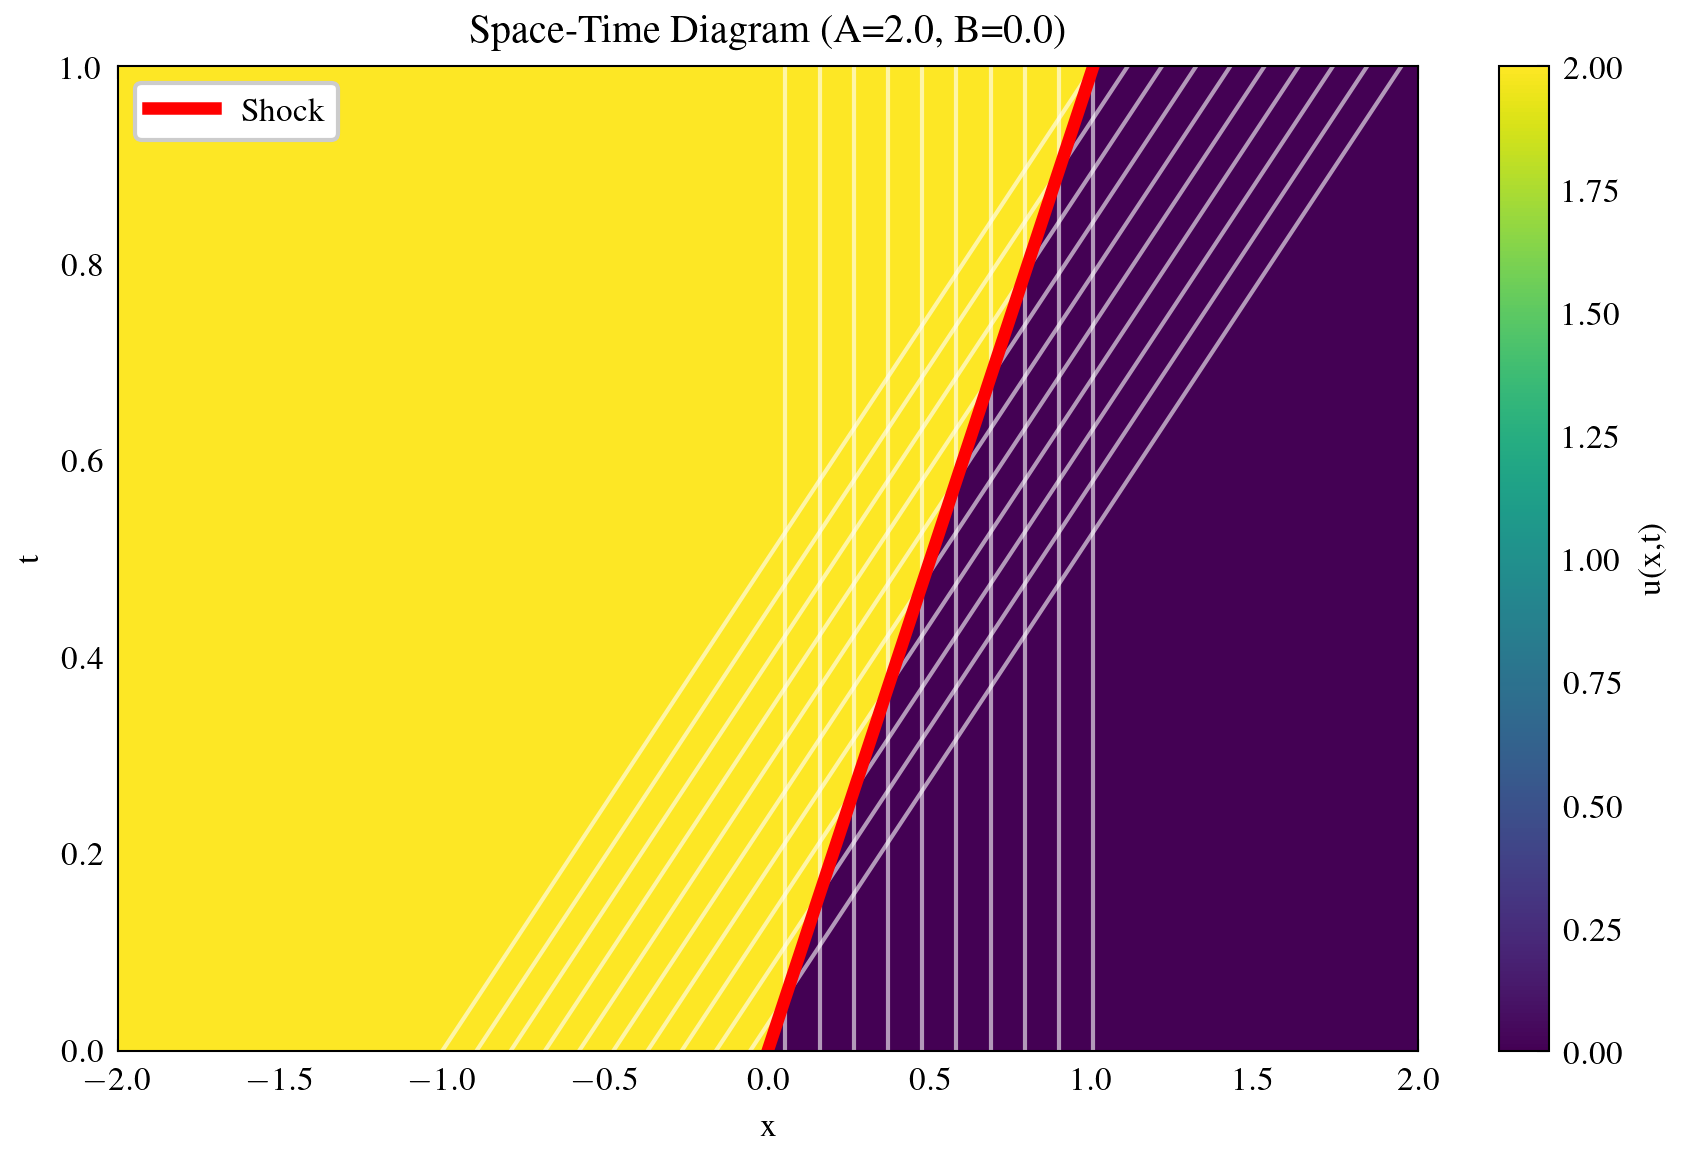

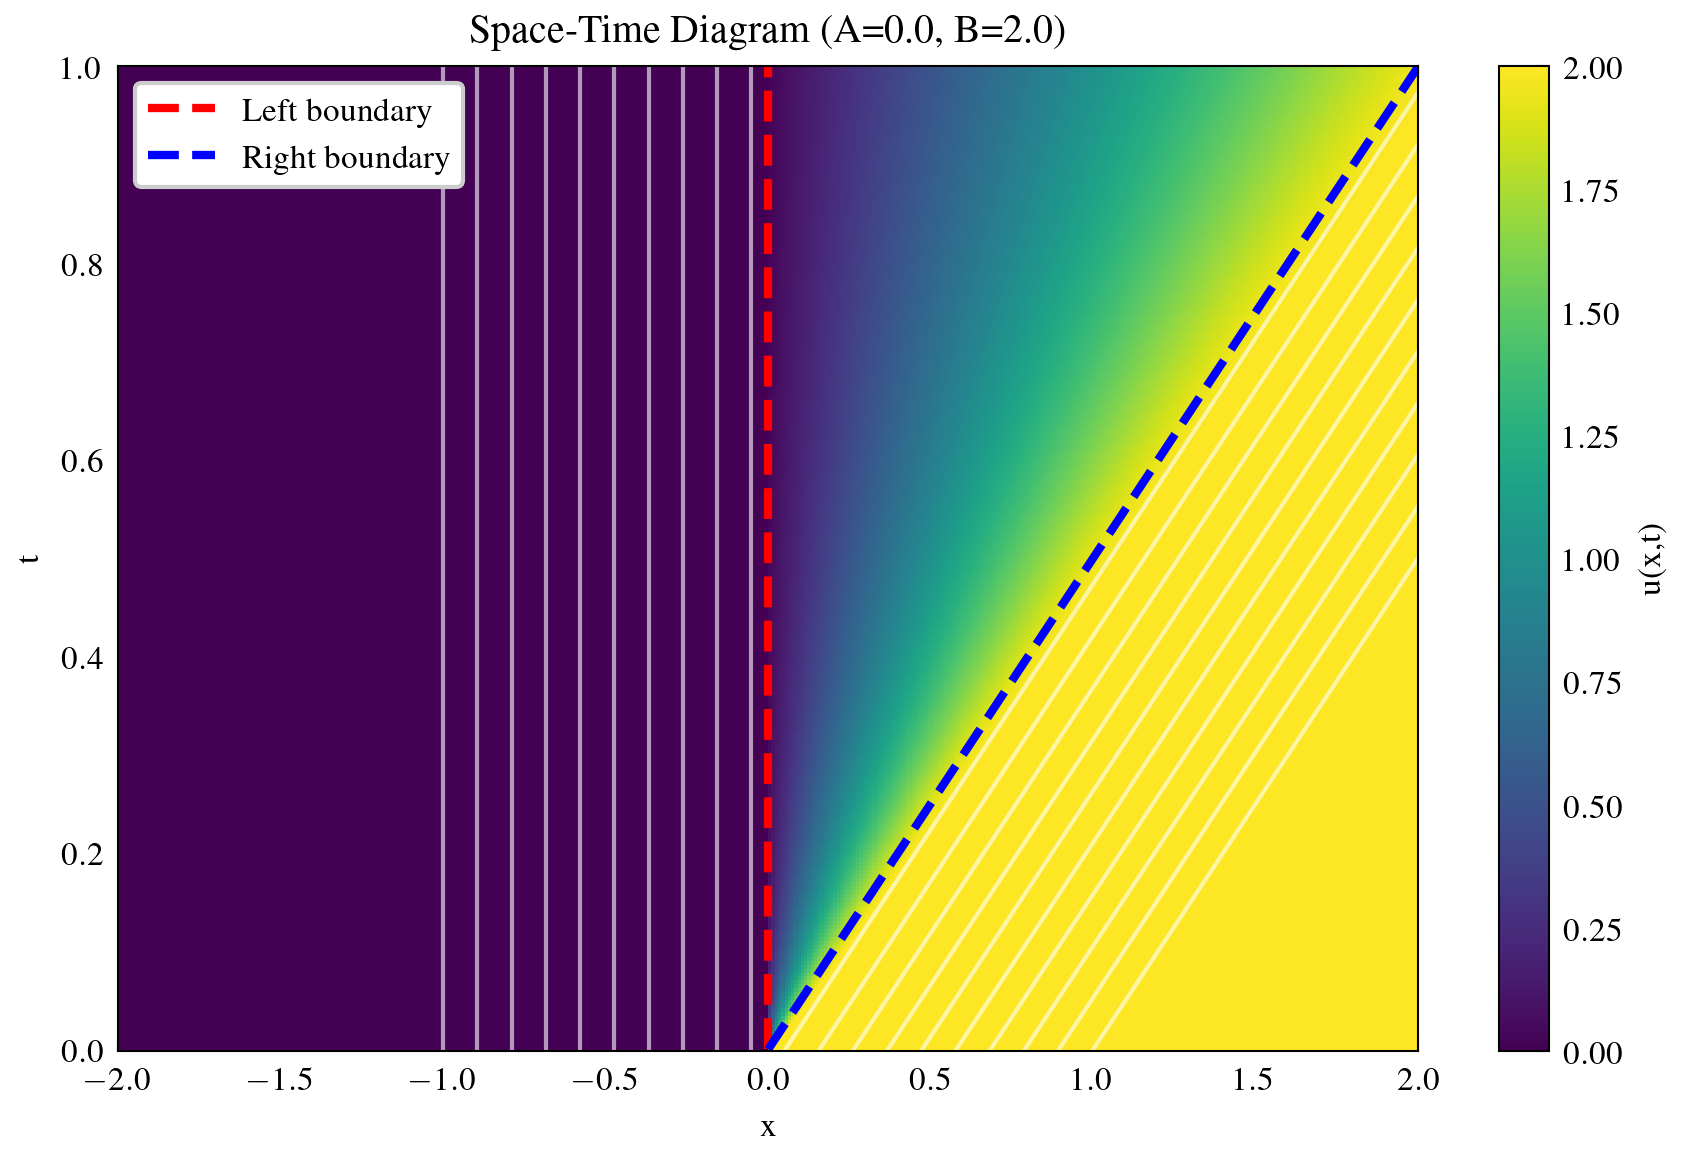

In [5]:
def plot_space_time(A, B):
    Nx = 400
    x = np.linspace(-2, 2, Nx)
    dx = x[1] - x[0]
    CFL = 0.8
    t_final = 1.0

    u = np.where(x < 0, A, B).astype(float)
    U = [u.copy()]
    t_vals = [0.0]
    t = 0.0

    while t < t_final:
        dt = CFL * dx / (np.max(np.abs(u)) + 1e-6)
        if t + dt > t_final:
            dt = t_final - t

        F = godunov_flux(u[:-1], u[1:])
        u[1:-1] -= dt / dx * (F[1:] - F[:-1])

        t += dt
        U.append(u.copy())
        t_vals.append(t)

    U = np.array(U)
    t_vals = np.array(t_vals)

    plt.style.use(["science", "ieee", "grid"])
    plt.figure(figsize=(6, 4), dpi=300)

    plt.pcolormesh(x, t_vals, U, shading="auto")

    cbar = plt.colorbar()
    cbar.set_label("u(x,t)")

    x0s = np.linspace(-1, 1, 20)
    t_char = np.linspace(0, t_final, 200)

    for x0 in x0s:
        u0 = A if x0 < 0 else B
        x_char = x0 + u0 * t_char
        plt.plot(x_char, t_char, "w-", alpha=0.6, linewidth=1)

    if A > B:
        s = 0.5 * (A + B)
        plt.plot(s * t_char, t_char, "r", linewidth=3, label="Shock")
    else:
        plt.plot(A * t_char, t_char, "r--", linewidth=2, label="Left boundary")
        plt.plot(B * t_char, t_char, "b--", linewidth=2, label="Right boundary")

    plt.xlabel("x")
    plt.ylabel("t")
    plt.title(f"Space-Time Diagram (A={A}, B={B})")
    plt.legend(loc="upper left")
    plt.grid(alpha=0.3)
    plt.xlim(-2, 2)
    plt.tight_layout()
    plt.show()


plot_space_time(2.0, 0.0)
plot_space_time(0.0, 2.0)

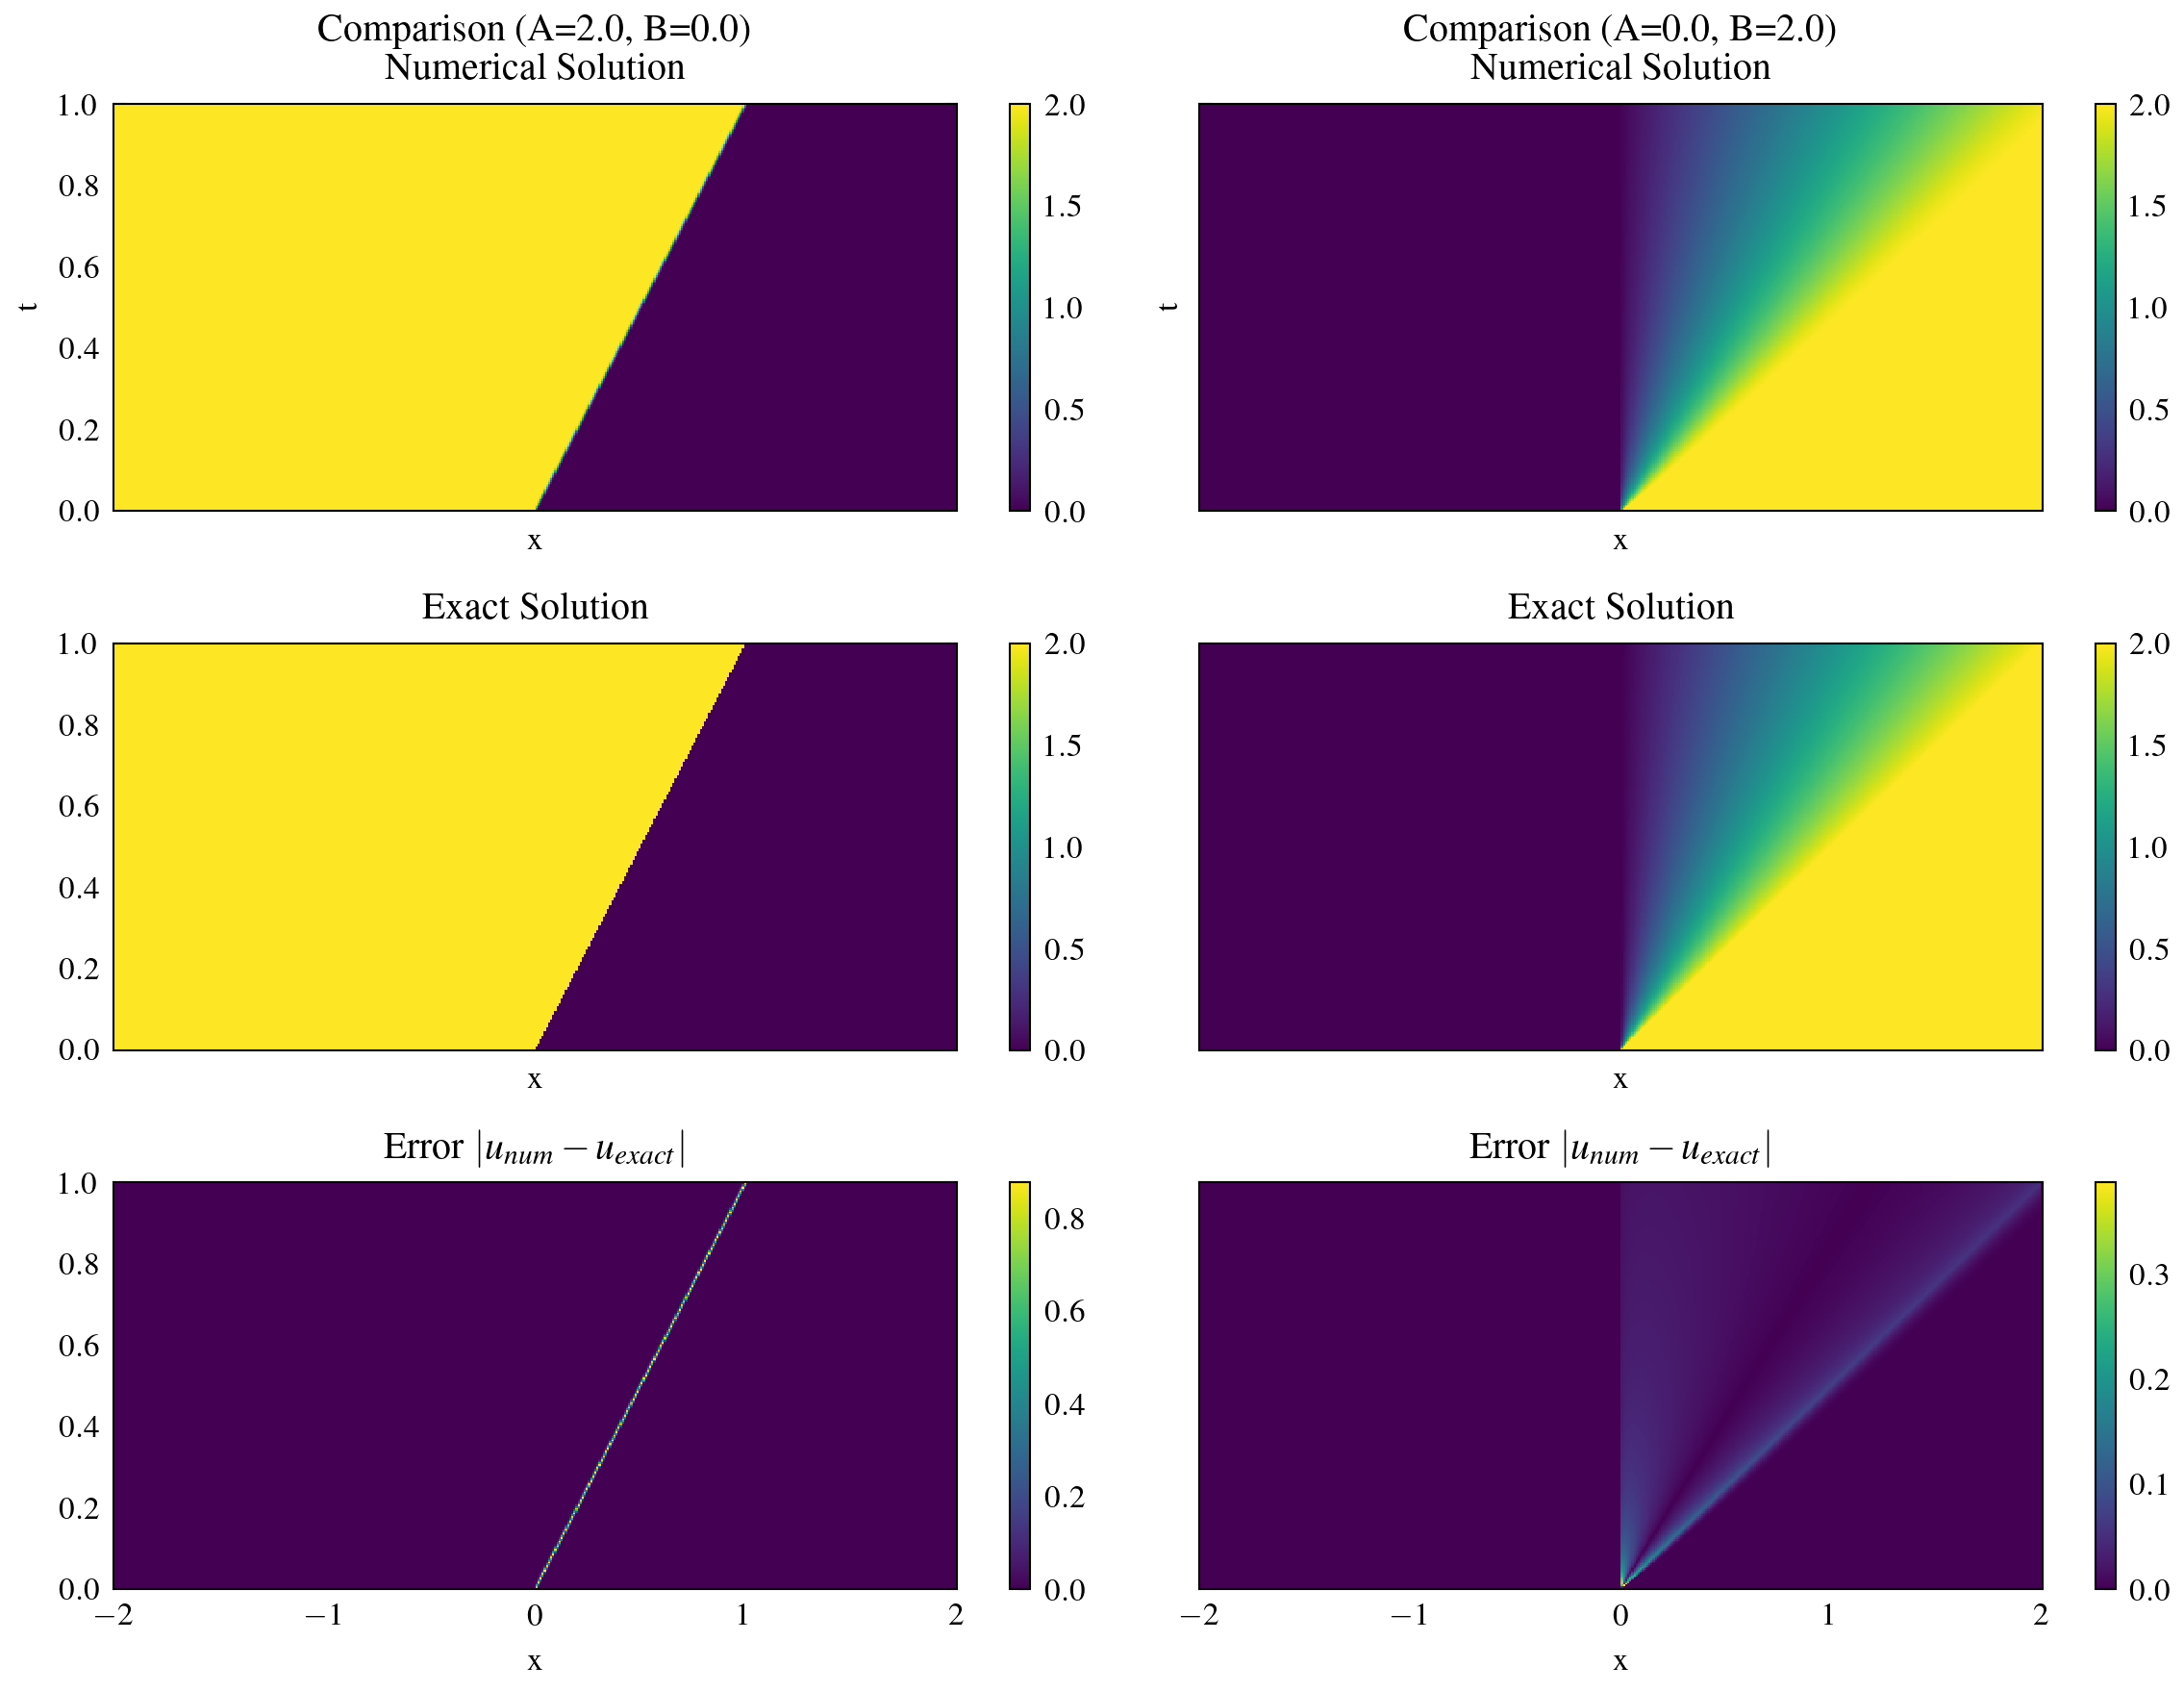

In [6]:
def plot_space_time_comparison(A, B):
    Nx = 400
    x = np.linspace(-2, 2, Nx)
    dx = x[1] - x[0]
    CFL = 0.8
    t_final = 1.0

    u = np.where(x < 0, A, B).astype(float)

    U_num = [u.copy()]
    U_ex = [exact(x, 0.0, A, B)]
    t_vals = [0.0]

    t = 0.0
    while t < t_final:
        dt = CFL * dx / (np.max(np.abs(u)) + 1e-6)
        if t + dt > t_final:
            dt = t_final - t

        F = godunov_flux(u[:-1], u[1:])
        u[1:-1] -= dt / dx * (F[1:] - F[:-1])

        t += dt

        U_num.append(u.copy())
        U_ex.append(exact(x, t, A, B))
        t_vals.append(t)

    U_num = np.array(U_num)
    U_ex = np.array(U_ex)
    t_vals = np.array(t_vals)

    error = np.abs(U_num - U_ex)

    return U_num, U_ex, error, x, t_vals


U_num1, U_ex1, error1, x1, t_vals1 = plot_space_time_comparison(2.0, 0.0)
U_num2, U_ex2, error2, x2, t_vals2 = plot_space_time_comparison(0.0, 2.0)

plt.style.use(["science", "ieee", "grid"])
fig, axes = plt.subplots(3, 2, figsize=(8, 6), sharex=True, sharey=True, dpi=300)

vmin = min(U_num1.min(), U_ex1.min(), U_num2.min(), U_ex2.min())
vmax = max(U_num1.max(), U_ex1.max(), U_num2.max(), U_ex2.max())

im0 = axes[0, 0].pcolormesh(x1, t_vals1, U_num1, shading="auto", vmin=vmin, vmax=vmax)
axes[0, 0].set_title(f"Comparison (A={2.0}, B={0.0}) \n Numerical Solution")
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("t")

im1 = axes[1, 0].pcolormesh(x1, t_vals1, U_ex1, shading="auto", vmin=vmin, vmax=vmax)
axes[1, 0].set_title("Exact Solution")
axes[1, 0].set_xlabel("x")

im2 = axes[2, 0].pcolormesh(x1, t_vals1, error1, shading="auto")
axes[2, 0].set_title(r"Error $|u_{num} - u_{exact}|$")
axes[2, 0].set_xlabel("x")

fig.colorbar(im0, ax=axes[0, 0])
fig.colorbar(im1, ax=axes[1, 0])
fig.colorbar(im2, ax=axes[2, 0])

im3 = axes[0, 1].pcolormesh(x2, t_vals2, U_num2, shading="auto", vmin=vmin, vmax=vmax)
axes[0, 1].set_title(f"Comparison (A={0.0}, B={2.0}) \n Numerical Solution")
axes[0, 1].set_xlabel("x")
axes[0, 1].set_ylabel("t")

im4 = axes[1, 1].pcolormesh(x2, t_vals2, U_ex2, shading="auto", vmin=vmin, vmax=vmax)
axes[1, 1].set_title("Exact Solution")
axes[1, 1].set_xlabel("x")

im5 = axes[2, 1].pcolormesh(x2, t_vals2, error2, shading="auto")
axes[2, 1].set_title(r"Error $|u_{num} - u_{exact}|$")
axes[2, 1].set_xlabel("x")

fig.colorbar(im3, ax=axes[0, 1])
fig.colorbar(im4, ax=axes[1, 1])
fig.colorbar(im5, ax=axes[2, 1])

plt.tight_layout()
plt.show()

### Problem 4

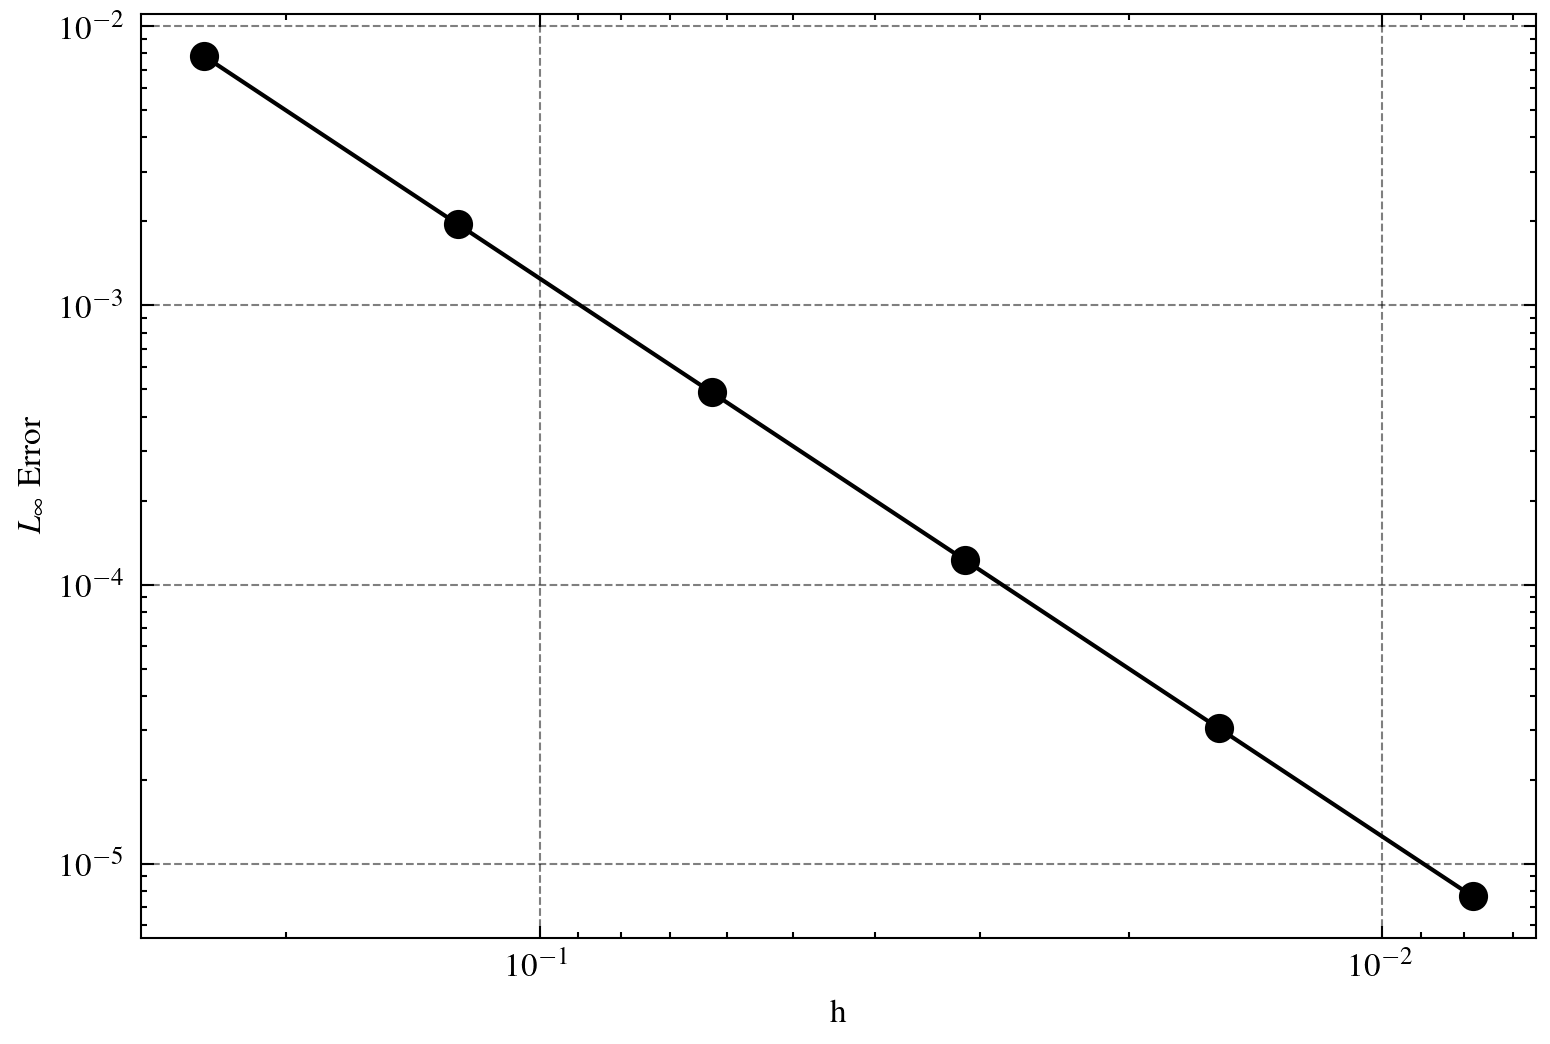

In [7]:
def exact_solution(x):
    return 0.5 * (1 - x**2)


def fem_hat_strict(N):
    h = 1.0 / N
    x = np.linspace(0, 1, N + 1)

    K = np.zeros((N + 1, N + 1))
    F = np.zeros(N + 1)

    for e in range(N):
        Ke = (1 / h) * np.array([[1, -1], [-1, 1]])
        Fe = h / 2 * np.array([1, 1])

        nodes = [e, e + 1]

        for i in range(2):
            F[nodes[i]] += Fe[i]
            for j in range(2):
                K[nodes[i], nodes[j]] += Ke[i, j]

    # Dirichlet
    K = K[:-1, :-1]
    F = F[:-1]

    U = np.linalg.solve(K, F)
    U = np.append(U, 0)

    return x, U


def compute_L_infinity_error(x, U):
    N = len(x) - 1
    err = 0.0

    for e in range(N):
        xL, xR = x[e], x[e + 1]
        UL, UR = U[e], U[e + 1]

        xg = (xR + xL) / 2
        uh = UL * (xR - xg) / (xR - xL) + UR * (xg - xL) / (xR - xL)
        err = max(err, np.abs(exact_solution(xg) - uh))

    return err


Ns = [4, 8, 16, 32, 64, 128]
errors = []
hs = []

for N in Ns:
    x, U = fem_hat_strict(N)
    err = compute_L_infinity_error(x, U)

    errors.append(err)
    hs.append(1 / N)

plt.style.use(["science", "ieee", "grid"])
plt.figure(figsize=(6, 4), dpi=300)
plt.loglog(hs, errors, marker="o")
plt.gca().invert_xaxis()
plt.xlabel("h")
plt.ylabel("$L_\\infty$ Error")
plt.grid(True)
plt.show()

In [8]:
def basis(xi):
    phiL = 1 - xi
    phiR = xi
    psi = 4 * xi * (1 - xi)
    return np.array([phiL, psi, phiR])


def dbasis(xi):
    dphiL = -1
    dphiR = 1
    dpsi = 4 * (1 - 2 * xi)
    return np.array([dphiL, dpsi, dphiR])


def fem_bubble(N):
    h = 1.0 / N
    ndof = 2 * N + 1

    K = np.zeros((ndof, ndof))
    F = np.zeros(ndof)

    gp = [-np.sqrt(3 / 5), 0, np.sqrt(3 / 5)]
    w = [5 / 9, 8 / 9, 5 / 9]

    for e in range(N):
        # DOF indices
        iL = 2 * e
        iB = 2 * e + 1
        iR = 2 * e + 2

        idx = [iL, iB, iR]

        Ke = np.zeros((3, 3))
        Fe = np.zeros(3)

        for k in range(3):
            xi_hat = gp[k]
            weight = w[k]

            # map [-1,1] → [0,1]
            xi = 0.5 * (xi_hat + 1)

            phi = basis(xi)
            dphi = dbasis(xi)

            # Jacobian
            dx_dxi = h
            dphi_dx = dphi / h

            for i in range(3):
                for j in range(3):
                    Ke[i, j] += weight * dphi_dx[i] * dphi_dx[j] * dx_dxi * 0.5

                Fe[i] += weight * phi[i] * dx_dxi * 0.5

        for i in range(3):
            F[idx[i]] += Fe[i]
            for j in range(3):
                K[idx[i], idx[j]] += Ke[i, j]

    K = K[:-1, :-1]
    F = F[:-1]

    U = np.linalg.solve(K, F)
    U = np.append(U, 0)

    return U


def eval_uh(U, N, x):
    h = 1.0 / N
    e = min(int(x / h), N - 1)

    xi = (x - e * h) / h

    phi = basis(xi)

    iL = 2 * e
    iB = 2 * e + 1
    iR = 2 * e + 2

    return U[iL] * phi[0] + U[iB] * phi[1] + U[iR] * phi[2]


def compute_L2(U, N):
    h = 1.0 / N
    err = 0.0

    gp = [-np.sqrt(3 / 5), 0, np.sqrt(3 / 5)]
    w = [5 / 9, 8 / 9, 5 / 9]

    for e in range(N):
        for k in range(3):
            xi_hat = gp[k]
            xi = 0.5 * (xi_hat + 1)

            x = e * h + xi * h

            uh = eval_uh(U, N, x)
            err += w[k] * (exact_solution(x) - uh) ** 2 * h * 0.5
    return np.sqrt(err)


# test
for N in [4, 8, 16, 32, 64]:
    U = fem_bubble(N)
    err = compute_L2(U, N)
    print(N, err)

4 6.399956843759611e-18
8 2.050769993508608e-17
16 1.7835775660990916e-17
32 2.0430851098474504e-17
64 1.9645233601639664e-17


### Problem 6

In [9]:
textT = Polygon(
    [
        [-3.7, 1.2],
        [-3.7, 0.75],
        [-3, 0.75],
        [-3, -1.2],
        [-2.5, -1.2],
        [-2.5, 0.75],
        [-1.8, 0.75],
        [-1.8, 1.2],
    ]
)
textH = Polygon(
    [
        [-1.1, 1.2],
        [-1.1, -1.2],
        [-0.6, -1.2],
        [-0.6, -0.2],
        [0.4, -0.2],
        [0.4, -1.2],
        [0.9, -1.2],
        [0.9, 1.2],
        [0.4, 1.2],
        [0.4, 0.2],
        [-0.6, 0.2],
        [-0.6, 1.2],
    ]
)
textU = Polygon(
    [
        [1.8, -1.2],
        [3.6, -1.2],
        [3.6, 1.2],
        [3.2, 1.2],
        [3.2, -0.75],
        [2.2, -0.75],
        [2.2, 1.2],
        [1.8, 1.2],
    ]
)

v = 0.2
TL = 1
TH = 10
L2 = 5
dx = 0.1
dy = 0.1
dt = 0.01
time_steps = 100

nx = int((L2 * 2) / dx) + 1
ny = int((L2 * 2) / dy) + 1

T = np.ones((nx, ny)) * TL
is_inside = np.ones((nx, ny), dtype=bool)
Ts = [T.copy()]

for i in range(nx):
    for j in range(ny):
        x = i * dx - L2
        y = j * dy - L2
        # If inside the inner boundary, set temperature to TH
        if (
            textT.contains_point([x, y])
            or textH.contains_point([x, y])
            or textU.contains_point([x, y])
        ):
            T[i, j] = TH
            is_inside[i, j] = False
        # If between the inner and outer boundary, set temperature to TL
        elif abs(x) < L2 and abs(y) < L2:
            T[i, j] = TL
        # If on the outer boundary, set temperature to TL
        if abs(x) >= L2 or abs(y) >= L2:
            T[i, j] = TL

for n in range(time_steps):
    T_new = T.copy()
    for i in range(1, nx - 1):
        for j in range(1, ny - 1):
            if is_inside[i, j]:
                T_new[i, j] += (
                    v
                    * dt
                    * (
                        (T[i + 1, j] - 2 * T[i, j] + T[i - 1, j]) / dx**2
                        + (T[i, j + 1] - 2 * T[i, j] + T[i, j - 1]) / dy**2
                    )
                )
    T = T_new
    Ts.append(T.copy())


plt.style.use(["science", "ieee", "grid"])
fig, ax = plt.subplots(figsize=(8, 6), dpi=96)

im = ax.imshow(
    Ts[0].T,
    extent=[-L2, L2, -L2, L2],
    origin="lower",
    cmap="plasma",
    animated=True,
    vmin=TL,
    vmax=TH,
)

im.set_clim(TL, TH)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Temperature")

ax.set_xlabel("x")
ax.set_ylabel("y")
title = ax.set_title("Heat Diffusion Simulation")


def update(frame):
    im.set_array(Ts[frame].T)
    return [im]


anim = FuncAnimation(
    fig,
    update,
    frames=len(Ts),
    interval=24,
    blit=True,
)

anim.save("../out/heat_diffusion.gif", writer="pillow")
plt.close(fig)

![heat_diffusion](../out/heat_diffusion.gif)

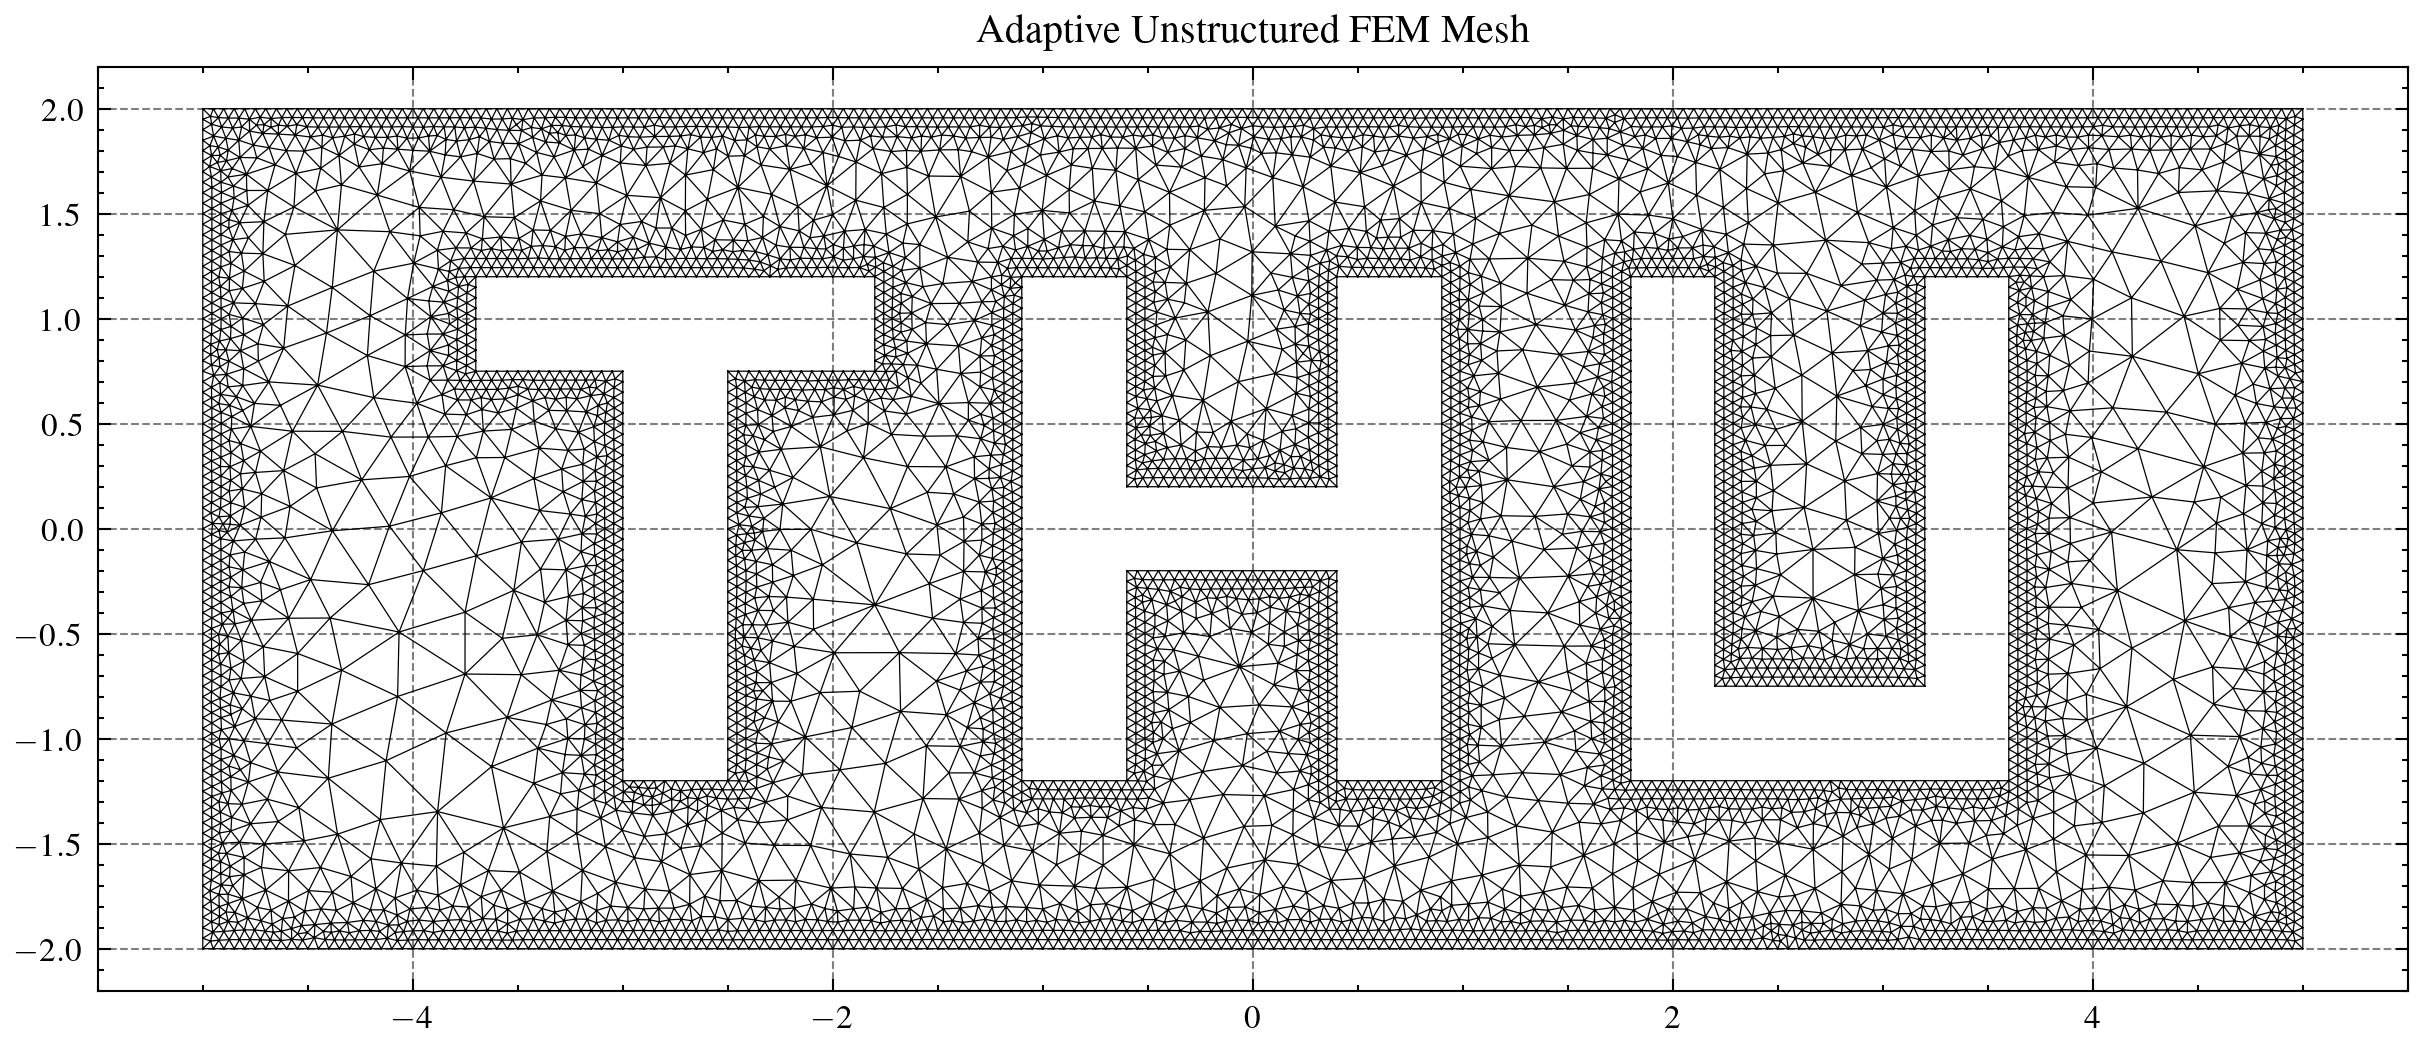

In [10]:
import skfem as fem
import matplotlib.tri as mtri

import scipy.sparse.linalg as spla

from skfem.utils import enforce
from skfem.helpers import dot, grad
from matplotlib.animation import ArtistAnimation


mesh = fem.Mesh.load("../out/thu_mesh.msh")
element = fem.ElementTriP1()
basis = fem.Basis(mesh, element)


@fem.BilinearForm
def mass(u, v, w):
    return u * v


@fem.BilinearForm
def laplace(u, v, w):
    return dot(grad(u), grad(v))


M = fem.asm(mass, basis)
K = fem.asm(laplace, basis)

boundary_facets = mesh.boundary_facets()
midpoints = mesh.p[:, mesh.facets[:, boundary_facets]].mean(axis=1)


outer_mask = (
    (midpoints[0] < -4.0)
    | (midpoints[0] > 4.0)
    | (midpoints[1] < -1.5)
    | (midpoints[1] > 1.5)
)
inner_mask = (
    (midpoints[0] > -4.0)
    & (midpoints[0] < 4.0)
    & (midpoints[1] > -1.5)
    & (midpoints[1] < 1.5)
)

dofs_L = basis.get_dofs(boundary_facets[outer_mask]).all()
dofs_H = basis.get_dofs(boundary_facets[inner_mask]).all()

T_L, T_H, v_coef = 1.0, 10.0, 0.2
dt, t_end = 0.05, 2.0

A = M + v_coef * dt * K
u = np.full(basis.N, T_L)

D_bnd = np.concatenate([dofs_L, dofs_H])
u_bc = np.zeros(basis.N)
u_bc[dofs_L] = T_L
u_bc[dofs_H] = T_H

numberOfFrames = 120
save_times = np.linspace(0, 2, numberOfFrames + 1)
frames_u = []

t = 0.0
save_idx = 0


while t <= t_end + 1e-5:
    if t >= save_times[save_idx] - 1e-5:
        frames_u.append(u.copy())
        save_idx += 1
        if save_idx > len(save_times) - 1:
            break

    b = M @ u
    A_bc, b_bc = enforce(A, b, D=D_bnd, x=u_bc)
    u = spla.spsolve(A_bc, b_bc)
    t += dt


triang = mtri.Triangulation(mesh.p[0], mesh.p[1], mesh.t.T)
plt.style.use(["science", "ieee", "grid"])
fig_mesh, ax_mesh = plt.subplots(figsize=(10, 4), dpi=300)
ax_mesh.set_aspect("equal")
ax_mesh.triplot(triang, lw=0.3, color="black")
ax_mesh.set_title("Adaptive Unstructured FEM Mesh")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4), dpi=96)
ax.set_aspect("equal")
ax.set_xlim(-5, 5)
ax.set_ylim(-2, 2)
ax.set_axis_off()

ims = []
for u_frame in frames_u:
    im = ax.tripcolor(
        triang, u_frame, shading="gouraud", cmap="turbo", vmin=T_L, vmax=T_H
    )
    ims.append([im])

ani = ArtistAnimation(fig, ims, interval=1000 * 4 / numberOfFrames, blit=True)

ani.save("../out/THU_FEM.gif", writer="pillow")
plt.close(fig)

![THU_FEM](../out/THU_FEM.gif)